<a href="https://colab.research.google.com/github/LaxmiBandi/Machine_Learning/blob/main/lineRregression_power_prediction%20_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/test.csv')
df.head()

,ID,datetime,temperature,var1,pressure,windspeed,var2
0,552,2013-07-24 00:00:00,-10.0,-16.4,1011.0,263.280,A
1,553,2013-07-24 01:00:00,-10.0,-20.7,1011.0,267.175,A
2,554,2013-07-24 02:00:00,-10.7,-17.1,1003.0,269.555,A
3,555,2013-07-24 03:00:00,-13.6,-20.7,1008.0,273.060,A
4,556,2013-07-24 04:00:00,-10.7,-17.1,1006.0,1.765,A


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Sort data
df = df.sort_values('datetime')

# Handle missing values
df = df.dropna()

In [4]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [5]:
target = 'var1'   # demand proxy
features = ['temperature', 'pressure', 'windspeed', 'hour', 'day', 'month']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[features]
y = df[target]

# Time series split (IMPORTANT: no shuffle)
X_train, X_test = X[:int(0.8*len(X))], X[int(0.8*len(X)):]
y_train, y_test = y[:int(0.8*len(y))], y[int(0.8*len(y)):]

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 3.9852712607084095


In [8]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02)

df['anomaly'] = iso.fit_predict(df[[target]])

# Convert to readable labels
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

In [9]:
def risk_level(x):
    if x == -1:
        return "HIGH"
    else:
        return "LOW"

df['risk'] = df['anomaly'].apply(risk_level)

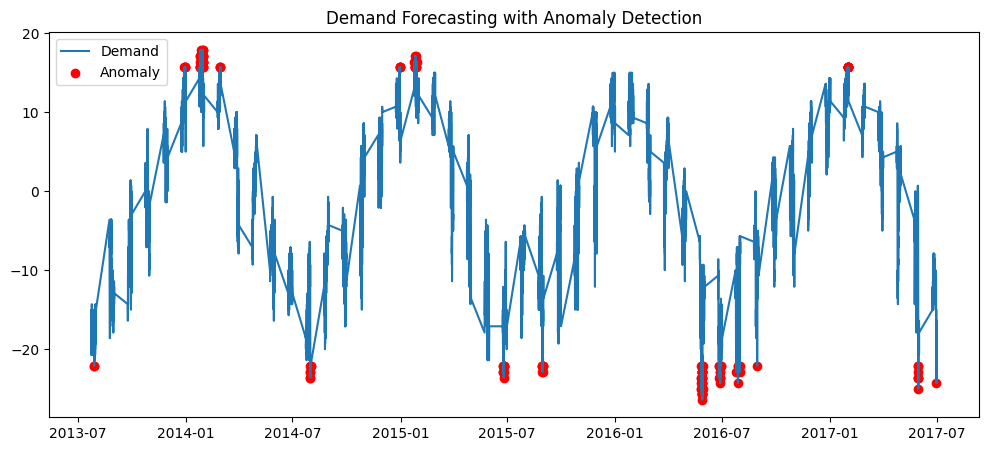

In [10]:
plt.figure(figsize=(12,5))

# Plot demand
plt.plot(df['datetime'], df[target], label='Demand')

# Highlight anomalies
anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies['datetime'], anomalies[target], color='red', label='Anomaly')

plt.legend()
plt.title("Demand Forecasting with Anomaly Detection")
plt.show()

In [16]:
import time

for i in range(len(X_test)):
    sample = X_test.iloc[i:i+1]

    pred = model.predict(sample)

    print(f"Time: {df['datetime'].iloc[i]} → Predicted Demand: {pred[0]}")

    time.sleep(1)  # simulate real-time (1 second delay)

Time: 2013-07-24 00:00:00 → Predicted Demand: 7.317014422487574
Time: 2013-07-24 01:00:00 → Predicted Demand: 4.032672066564828
Time: 2013-07-24 02:00:00 → Predicted Demand: 3.1457780805915263
Time: 2013-07-24 03:00:00 → Predicted Demand: 3.7048031899049647
Time: 2013-07-24 04:00:00 → Predicted Demand: 2.45684145140811
Time: 2013-07-24 05:00:00 → Predicted Demand: 0.4662915187779504
Time: 2013-07-24 06:00:00 → Predicted Demand: 1.0473369980090013
Time: 2013-07-24 07:00:00 → Predicted Demand: -0.9954401417980421
Time: 2013-07-24 08:00:00 → Predicted Demand: -3.2968571290329862
Time: 2013-07-24 09:00:00 → Predicted Demand: -3.3084773070162328
Time: 2013-07-24 10:00:00 → Predicted Demand: 2.959833141053565
Time: 2013-07-24 11:00:00 → Predicted Demand: -0.4893929246579205
Time: 2013-07-24 12:00:00 → Predicted Demand: -3.725760657530884
Time: 2013-07-24 13:00:00 → Predicted Demand: -2.2264538152844295
Time: 2013-07-24 14:00:00 → Predicted Demand: -1.4170672696559734
Time: 2013-07-24 15:00:0

KeyboardInterrupt: 

In [ ]:
for i in range(len(df)):
    value = df.iloc[i][target]

    anomaly = iso.predict([[value]])[0]

    if anomaly == -1:
        print(f"⚠ ALERT at {df['datetime'].iloc[i]} → HIGH RISK")
    else:
        print(f"Normal at {df['datetime'].iloc[i]}")

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3.9852712607084095
RMSE: 5.0279218382605215


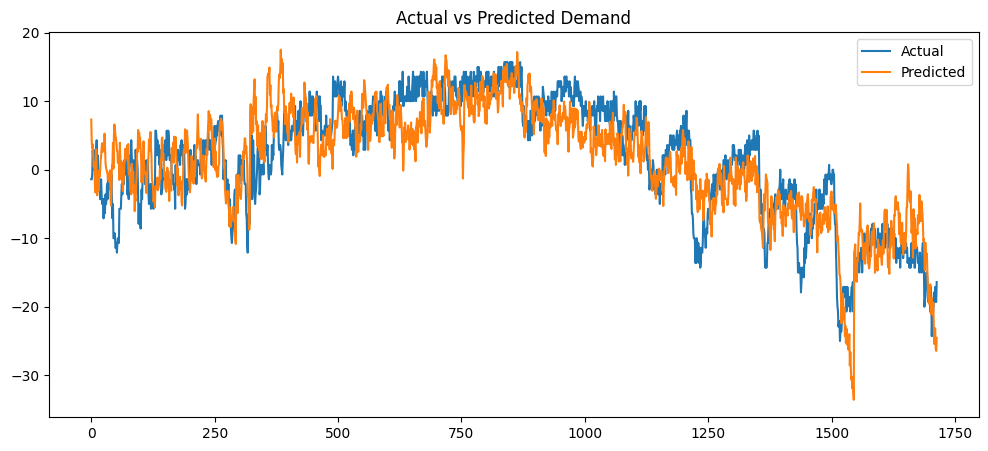

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

In [13]:
print(df['anomaly_label'].value_counts())

anomaly_label
Normal     8410
Anomaly     158
Name: count, dtype: int64


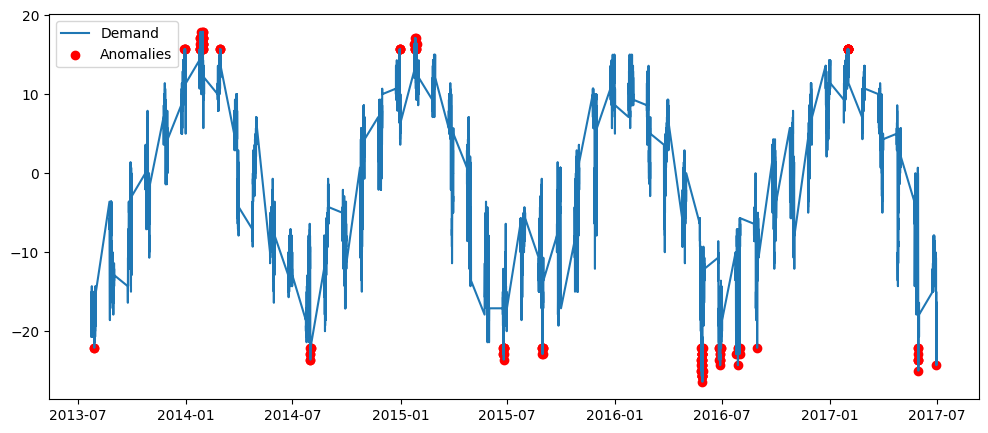

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df['datetime'], df['var1'], label='Demand')

anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies['datetime'], anomalies['var1'], color='red', label='Anomalies')

plt.legend()
plt.show()

In [15]:
print(df[['datetime', 'var1', 'risk']].head(10))

             datetime  var1 risk
0 2013-07-24 00:00:00 -16.4  LOW
1 2013-07-24 01:00:00 -20.7  LOW
2 2013-07-24 02:00:00 -17.1  LOW
3 2013-07-24 03:00:00 -20.7  LOW
4 2013-07-24 04:00:00 -17.1  LOW
5 2013-07-24 05:00:00 -20.0  LOW
6 2013-07-24 06:00:00 -20.7  LOW
7 2013-07-24 07:00:00 -17.9  LOW
8 2013-07-24 08:00:00 -17.1  LOW
9 2013-07-24 09:00:00 -19.3  LOW
